# Validierung: aFRR Aktivierungspreis (Bids-VWAP vs. TSO-Aggregat)

## Ziel
Dieses Notebook zeigt nachvollziehbar, ob der stündliche, aus anonymen Geboten rekonstruierte Aktivierungspreis mit dem publizierten TSO-Aggregat konsistent ist.

Verglichen werden direkt:
- `afrr_bid_vwap_activation_price_pos`, `afrr_bid_vwap_activation_price_neg` (Bids-basiert)
- `afrr_avg_activation_price_pos`, `afrr_avg_activation_price_neg` (TSO-Aggregat)

## Datenbasis
- Datei: `data/processed/all_data.parquet`
- Zeitachse: `timestamp_utc` (UTC)


In [9]:
from pathlib import Path
import subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 200)


In [10]:
DATA_PATH = Path('../data/processed/all_data.parquet')
if not DATA_PATH.exists():
    raise FileNotFoundError(f'Missing file: {DATA_PATH}')

df = pd.read_parquet(DATA_PATH)

required_cols = [
    'timestamp_utc',
    'afrr_bid_vwap_activation_price_pos',
    'afrr_bid_vwap_activation_price_neg',
    'afrr_avg_activation_price_pos',
    'afrr_avg_activation_price_neg',
]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise KeyError(f"Missing required columns: {missing}")

df = df[required_cols].copy()
df['timestamp_utc'] = pd.to_datetime(df['timestamp_utc'], utc=True, errors='coerce')
df = df.dropna(subset=['timestamp_utc']).sort_values('timestamp_utc').set_index('timestamp_utc')

try:
    commit = subprocess.check_output(['git', 'rev-parse', '--short', 'HEAD'], text=True).strip()
except Exception:
    commit = 'n/a'

print('commit:', commit)
print('rows:', len(df))
print('range:', df.index.min(), '->', df.index.max())


commit: eaff5df
rows: 44572
range: 2020-11-30 23:00:00+00:00 -> 2026-01-01 02:00:00+00:00


## Methodik (dokumentiert)

### 1) Bids-basierter 15-Minuten-VWAP
Für jede Richtung (POS/NEG) und Viertelstunde:

$$
\text{VWAP}_{15m} = \frac{\sum_i \left(\text{price\_signed}_i \cdot \text{allocated\_mw}_i\right)}{\sum_i \text{allocated\_mw}_i}
$$

Dabei wird für NEG die Zahlungsrichtung (`ENERGY_PRICE_PAYMENT_DIRECTION`) im Vorzeichen von `price_signed` berücksichtigt.

### 2) Stündliche Aggregation
Volumengewichtet über die vier Viertelstunden (kein einfacher Mittelwert):

$$
\text{VWAP}_{1h} = \frac{\sum_q \left(\text{VWAP}_{15m,q} \cdot \text{vol}_{15m,q}\right)}{\sum_q \text{vol}_{15m,q}}
$$

Dieses Ergebnis liegt in `afrr_bid_vwap_activation_price_*`.


In [11]:
def _metrics(x: pd.Series, y: pd.Series) -> dict:
    m = pd.concat([x, y], axis=1).dropna()
    if m.empty:
        return {'rows': 0, 'mae': np.nan, 'bias_y_minus_x': np.nan, 'corr': np.nan}
    err = m.iloc[:, 1] - m.iloc[:, 0]
    return {
        'rows': int(len(m)),
        'mae': float(np.abs(err).mean()),
        'bias_y_minus_x': float(err.mean()),
        'corr': float(m.iloc[:, 0].corr(m.iloc[:, 1])) if len(m) > 1 else np.nan,
    }

metrics_df = pd.DataFrame([
    {'side': 'POS', **_metrics(df['afrr_bid_vwap_activation_price_pos'], df['afrr_avg_activation_price_pos'])},
    {'side': 'NEG', **_metrics(df['afrr_bid_vwap_activation_price_neg'], df['afrr_avg_activation_price_neg'])},
])
metrics_df


,side,rows,mae,bias_y_minus_x,corr
0,POS,44571,0.691290,0.063373,0.999928
1,NEG,44571,0.545792,-0.157610,0.999974


In [12]:
null_report = pd.DataFrame({
    'column': [
        'afrr_bid_vwap_activation_price_pos',
        'afrr_avg_activation_price_pos',
        'afrr_bid_vwap_activation_price_neg',
        'afrr_avg_activation_price_neg',
    ]
})
null_report['nulls'] = null_report['column'].map(lambda c: int(df[c].isna().sum()))
null_report['null_share'] = null_report['column'].map(lambda c: float(df[c].isna().mean()))
null_report


,column,nulls,null_share
0,afrr_bid_vwap_activation_price_pos,1,0.000022
1,afrr_avg_activation_price_pos,0,0.000000
2,afrr_bid_vwap_activation_price_neg,1,0.000022
3,afrr_avg_activation_price_neg,0,0.000000


In [13]:
# Fester Prüf-Tag für reproduzierbaren Vergleich
DAY = pd.Timestamp('2025-02-19 00:00:00+00:00')
start = DAY
end = DAY + pd.Timedelta(hours=23)

day_df = df.loc[start:end, [
    'afrr_bid_vwap_activation_price_pos',
    'afrr_avg_activation_price_pos',
    'afrr_bid_vwap_activation_price_neg',
    'afrr_avg_activation_price_neg',
]].copy()

if day_df.empty:
    raise ValueError(f'No rows for day window: {start} -> {end}')

day_df.head(24)


,afrr_bid_vwap_activation_price_pos,afrr_avg_activation_price_pos,afrr_bid_vwap_activation_price_neg,afrr_avg_activation_price_neg
timestamp_utc,,,,
2025-02-19 00:00:00+00:00,1661.461482,1660.7775,-1212.079904,-1250.6375
2025-02-19 01:00:00+00:00,1662.680190,1662.6950,-1080.890667,-1080.9025
2025-02-19 02:00:00+00:00,1609.443626,1610.8925,-1145.712455,-1146.7175
2025-02-19 03:00:00+00:00,1029.032462,1029.0375,-864.668804,-864.6700
2025-02-19 04:00:00+00:00,1006.512136,1006.5200,-861.121444,-861.1225
2025-02-19 05:00:00+00:00,1031.818283,1031.8275,-855.067461,-855.0975
2025-02-19 06:00:00+00:00,1090.666777,1090.6675,-789.007322,-789.0075
2025-02-19 07:00:00+00:00,1738.930954,1735.6275,-1201.071737,-1201.1550
2025-02-19 08:00:00+00:00,1585.475633,1588.4525,-1214.324018,-1214.4400


In [14]:
# Ausreißeranalyse auf Gesamtraum
cmp = pd.DataFrame(index=df.index)
cmp['diff_pos_abs'] = (df['afrr_bid_vwap_activation_price_pos'] - df['afrr_avg_activation_price_pos']).abs()
cmp['diff_neg_abs'] = (df['afrr_bid_vwap_activation_price_neg'] - df['afrr_avg_activation_price_neg']).abs()

print('Top 10 POS-Abweichungen:')
display(cmp['diff_pos_abs'].dropna().sort_values(ascending=False).head(10).to_frame('abs_diff_pos'))
print('Top 10 NEG-Abweichungen:')
display(cmp['diff_neg_abs'].dropna().sort_values(ascending=False).head(10).to_frame('abs_diff_neg'))


Top 10 POS-Abweichungen:


,abs_diff_pos
timestamp_utc,
2023-03-20 00:00:00+00:00,5955.309518
2023-01-20 06:00:00+00:00,1082.257450
2025-09-01 23:00:00+00:00,640.245195
2024-08-12 01:00:00+00:00,597.546304
2024-12-28 19:00:00+00:00,321.660418
2025-07-17 20:00:00+00:00,302.771148
2024-12-02 06:00:00+00:00,253.019850
2023-07-24 11:00:00+00:00,215.281771
2024-04-13 20:00:00+00:00,202.305376


Top 10 NEG-Abweichungen:


,abs_diff_neg
timestamp_utc,
2025-03-19 20:00:00+00:00,2279.268885
2024-01-19 13:00:00+00:00,925.831509
2023-06-22 23:00:00+00:00,540.999815
2025-06-29 17:00:00+00:00,525.992871
2023-11-20 19:00:00+00:00,516.624945
2024-08-02 23:00:00+00:00,490.728475
2025-03-11 00:00:00+00:00,394.461430
2025-03-02 19:00:00+00:00,331.626011
2024-12-11 19:00:00+00:00,324.772910


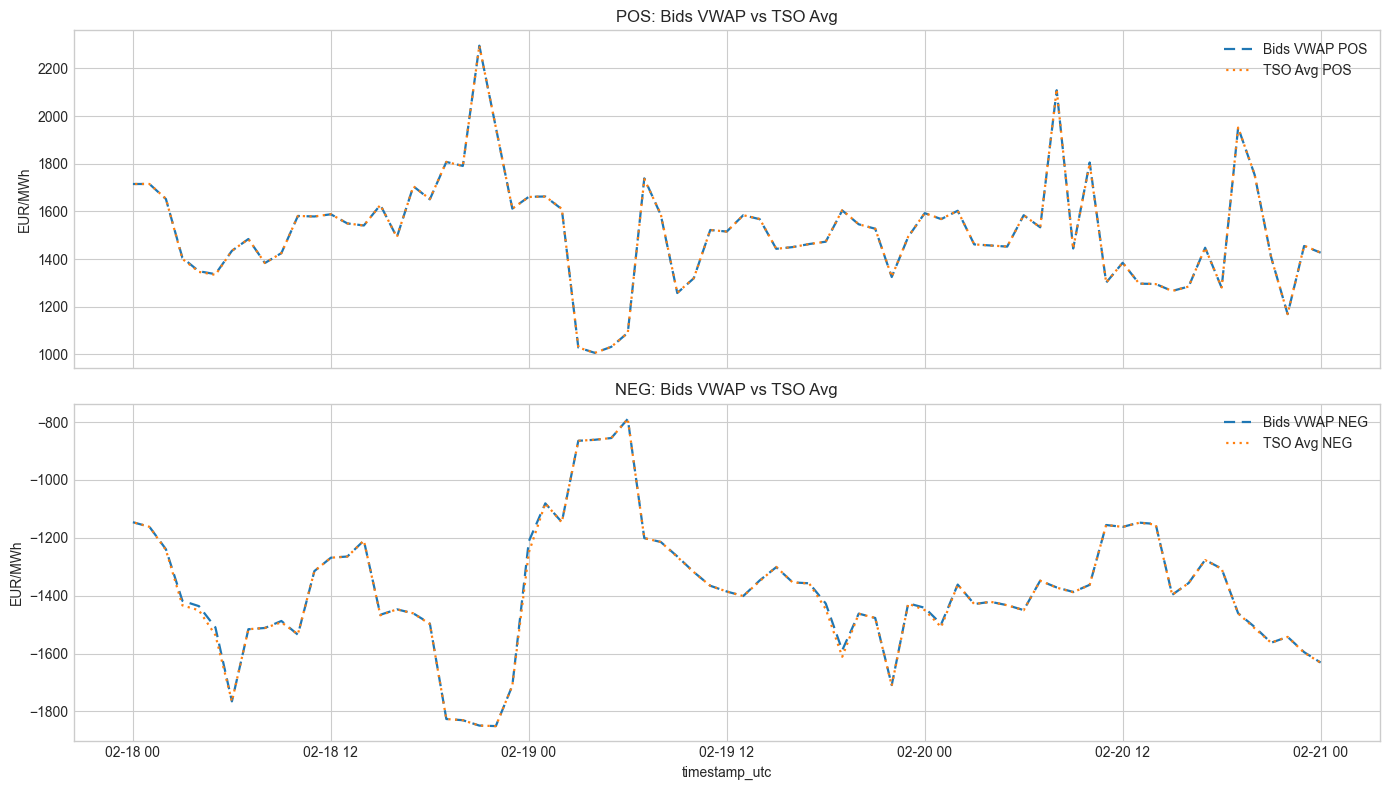

window: 2025-02-18 00:00:00+00:00 -> 2025-02-21 00:00:00+00:00


In [15]:
# Visualisierung: 72h um den Prüf-Tag
w_start = DAY - pd.Timedelta(hours=24)
w_end = DAY + pd.Timedelta(hours=48)
w = df.loc[w_start:w_end]

fig, ax = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax[0].plot(w.index, w['afrr_bid_vwap_activation_price_pos'], label='Bids VWAP POS', linewidth=1.6, linestyle=(0, (5, 3)))
ax[0].plot(w.index, w['afrr_avg_activation_price_pos'], label='TSO Avg POS', linewidth=1.6, linestyle=(2, (1, 2)))
ax[0].set_title('POS: Bids VWAP vs TSO Avg')
ax[0].set_ylabel('EUR/MWh')
ax[0].legend(loc='best')

ax[1].plot(w.index, w['afrr_bid_vwap_activation_price_neg'], label='Bids VWAP NEG', linewidth=1.6, linestyle=(0, (5, 3)))
ax[1].plot(w.index, w['afrr_avg_activation_price_neg'], label='TSO Avg NEG', linewidth=1.6, linestyle=(2, (1, 2)))
ax[1].set_title('NEG: Bids VWAP vs TSO Avg')
ax[1].set_ylabel('EUR/MWh')
ax[1].set_xlabel('timestamp_utc')
ax[1].legend(loc='best')

plt.tight_layout()
plt.show()
print('window:', w_start, '->', w.index.max())


## Fazit

- Die Prüfung nutzt direkte, feste Spaltennamen (kein Alias-Fallback), damit die Dokumentation reproduzierbar und auditierbar ist.
- Die zentrale Vergleichsfrage lautet: Wie nah liegt der bids-basierte stündliche VWAP (`afrr_bid_vwap_activation_price_*`) am TSO-Aggregat (`afrr_avg_activation_price_*`)?
- Die Kennzahlen (MAE/Bias/Korrelation), Tagesansicht (19.02.2025) und Top-Ausreißer sind die Kernbelege für die methodische Bewertung.
